# **KHAI THÁC DỮ LIỆU (DATA MINING)**

# **daily_food_nutrition_dataset**

# **I. Nạp dữ liệu**

**1.Tải dataset**

**Tải thư viện**

In [1]:
# Import thư viện cần thiết
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import warnings

# Tắt cảnh báo không cần thiết
warnings.simplefilter("ignore", UserWarning)

In [2]:
def load_Nutrition_data():
    dataset_path = Path("datasets/Nutrition_data")
    csv_file = dataset_path / "daily_food_nutrition_dataset.csv"

    if not csv_file.is_file():
        # Đảm bảo thư mục tồn tại
        dataset_path.mkdir(parents=True, exist_ok=True)

        # 🛠️ Lệnh đúng để tải dataset từ Kaggle
        os.system(f"kaggle datasets download -d adilshamim8/daily-food-and-nutrition-dataset -p {dataset_path} --unzip")

    if not csv_file.is_file():
        raise FileNotFoundError(f"Không tìm thấy file: {csv_file}")

    return pd.read_csv(csv_file)

# Gọi hàm để tải dữ liệu
Nutrition_data = load_Nutrition_data()
print(Nutrition_data.head())  # Xem trước dữ liệu


         Date  User_ID       Food_Item Category  Calories (kcal)  Protein (g)  \
0  2024-09-11      496            Eggs     Meat              173         42.4   
1  2024-12-17      201           Apple   Fruits               66         39.2   
2  2024-06-09      776  Chicken Breast     Meat              226         27.1   
3  2024-08-27      112          Banana   Fruits              116         43.4   
4  2024-07-28      622          Banana   Fruits              500         33.9   

   Carbohydrates (g)  Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0               83.7      1.5        1.5        12.7          752   
1               13.8      3.2        2.6        12.2          680   
2               79.1     25.8        3.2        44.7          295   
3               47.1     16.1        6.5        44.1          307   
4               75.8     47.0        7.8        19.4          358   

   Cholesterol (mg)  Meal_Type  Water_Intake (ml)  
0               125      Lunch                

**2.Cấu trúc dữ liệu**

In [3]:
Nutrition_data.head()

,Date,User_ID,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,2024-09-11,496,Eggs,Meat,173,42.4,83.7,1.5,1.5,12.7,752,125,Lunch,478
1,2024-12-17,201,Apple,Fruits,66,39.2,13.8,3.2,2.6,12.2,680,97,Lunch,466
2,2024-06-09,776,Chicken Breast,Meat,226,27.1,79.1,25.8,3.2,44.7,295,157,Breakfast,635
3,2024-08-27,112,Banana,Fruits,116,43.4,47.1,16.1,6.5,44.1,307,13,Snack,379
4,2024-07-28,622,Banana,Fruits,500,33.9,75.8,47.0,7.8,19.4,358,148,Lunch,471


In [4]:
Nutrition_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               10000 non-null  object 
 1   User_ID            10000 non-null  int64  
 2   Food_Item          10000 non-null  object 
 3   Category           10000 non-null  object 
 4   Calories (kcal)    10000 non-null  int64  
 5   Protein (g)        10000 non-null  float64
 6   Carbohydrates (g)  10000 non-null  float64
 7   Fat (g)            10000 non-null  float64
 8   Fiber (g)          10000 non-null  float64
 9   Sugars (g)         10000 non-null  float64
 10  Sodium (mg)        10000 non-null  int64  
 11  Cholesterol (mg)   10000 non-null  int64  
 12  Meal_Type          10000 non-null  object 
 13  Water_Intake (ml)  10000 non-null  int64  
dtypes: float64(5), int64(5), object(4)
memory usage: 1.1+ MB


In [5]:
Nutrition_data["Food_Item"].value_counts()

Food_Item
Milk              311
Orange            308
Pork Chop         307
Orange Juice      302
Carrot            301
Apple             299
Chocolate         299
Yogurt            298
Milkshake         297
Spinach           295
Quinoa            294
Coffee            292
Butter            292
Chicken Breast    290
Cookies           287
Cheese            286
Popcorn           285
Grapes            284
Banana            283
Rice              283
Chips             282
Beef Steak        282
Broccoli          280
Strawberry        279
Nuts              279
Green Tea         278
Potato            276
Water             276
Paneer            273
Oats              271
Salmon            270
Eggs              269
Pasta             269
Bread             267
Tomato            256
Name: count, dtype: int64

In [6]:
Nutrition_data.describe()

,User_ID,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Water_Intake (ml)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,498.706300,327.693900,25.523050,52.568550,25.43735,4.986940,25.052570,497.969000,151.886600,554.353600
std,289.123477,158.194716,14.131993,27.387152,14.14532,2.864984,14.480605,287.988001,87.360643,260.977642
min,1.000000,50.000000,1.000000,5.000000,1.00000,0.000000,0.000000,0.000000,0.000000,100.000000
25%,245.000000,190.000000,13.200000,28.800000,13.30000,2.500000,12.500000,249.750000,76.000000,327.000000
50%,492.000000,328.000000,25.500000,52.800000,25.30000,5.000000,25.000000,495.000000,153.000000,555.500000
75%,748.000000,464.000000,37.700000,76.400000,37.60000,7.500000,37.700000,749.000000,228.000000,783.000000
max,1000.000000,600.000000,50.000000,100.000000,50.00000,10.000000,50.000000,1000.000000,300.000000,1000.000000


In [7]:
print(Nutrition_data.columns)  # Danh sách cột

Index(['Date', 'User_ID', 'Food_Item', 'Category', 'Calories (kcal)',
       'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)',
       'Sugars (g)', 'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type',
       'Water_Intake (ml)'],
      dtype='object')


#  **II.Tiền xử lý dữ liệu**

In [8]:
import pandas as pd

# 🛠 1️⃣ Chuẩn hóa tên cột
Nutrition_data.columns = (
    Nutrition_data.columns.str.strip()   # Xóa khoảng trắng thừa
    .str.lower()                         # Chuyển thành chữ thường
    .str.replace(r"\s+", "_", regex=True)  # Thay khoảng trắng bằng "_"
)

print("✅ Tên cột sau khi chuẩn hóa:", Nutrition_data.columns.tolist())

# 🛠 2️⃣ Chuyển đổi kiểu dữ liệu
if "date" in Nutrition_data.columns:
    Nutrition_data["date"] = pd.to_datetime(Nutrition_data["date"], errors="coerce")  # Chuyển về datetime

if "user_id" in Nutrition_data.columns:
    Nutrition_data["user_id"] = Nutrition_data["user_id"].astype(str)  # Chuyển user_id thành chuỗi

# 🛠 3️⃣ Kiểm tra giá trị bị thiếu
missing_values = Nutrition_data.isnull().sum()
print("📌 Số lượng giá trị thiếu trong mỗi cột:\n", missing_values[missing_values > 0])  # Chỉ hiển thị cột có giá trị thiếu

# 🛠 4️⃣ Xóa hàng có quá nhiều dữ liệu bị thiếu (giữ lại ít nhất 70% dữ liệu hợp lệ)
threshold = int(Nutrition_data.shape[1] * 0.7)
Nutrition_data.dropna(thresh=threshold, inplace=True)

# 🛠 5️⃣ Xóa trùng lặp
duplicates = Nutrition_data.duplicated().sum()
if duplicates > 0:
    print(f"⚠️ Phát hiện {duplicates} bản ghi trùng lặp! Đang xóa...")
    Nutrition_data.drop_duplicates(inplace=True)

# 🛠 6️⃣ Reset index sau khi làm sạch dữ liệu
Nutrition_data.reset_index(drop=True, inplace=True)

print("✅ Dữ liệu sau tiền xử lý:", Nutrition_data.shape)


✅ Tên cột sau khi chuẩn hóa: ['date', 'user_id', 'food_item', 'category', 'calories_(kcal)', 'protein_(g)', 'carbohydrates_(g)', 'fat_(g)', 'fiber_(g)', 'sugars_(g)', 'sodium_(mg)', 'cholesterol_(mg)', 'meal_type', 'water_intake_(ml)']
📌 Số lượng giá trị thiếu trong mỗi cột:
 Series([], dtype: int64)
✅ Dữ liệu sau tiền xử lý: (10000, 14)


# **III.Trực quan hóa dữ liệu**

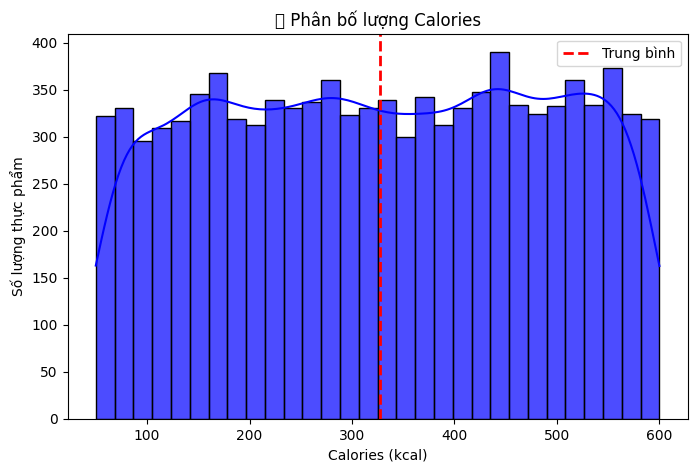

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(Nutrition_data['calories_(kcal)'], bins=30, kde=True, color='blue', alpha=0.7)
plt.axvline(Nutrition_data['calories_(kcal)'].mean(), color='red', linestyle='dashed', linewidth=2, label="Trung bình")
plt.title("📊 Phân bố lượng Calories")
plt.xlabel("Calories (kcal)")
plt.ylabel("Số lượng thực phẩm")
plt.legend()
plt.show()


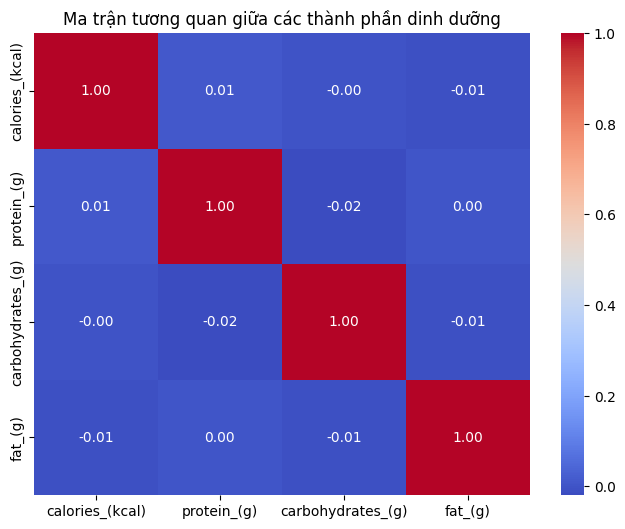

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(Nutrition_data[['calories_(kcal)', 'protein_(g)', 'carbohydrates_(g)', 'fat_(g)']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các thành phần dinh dưỡng")
plt.show()


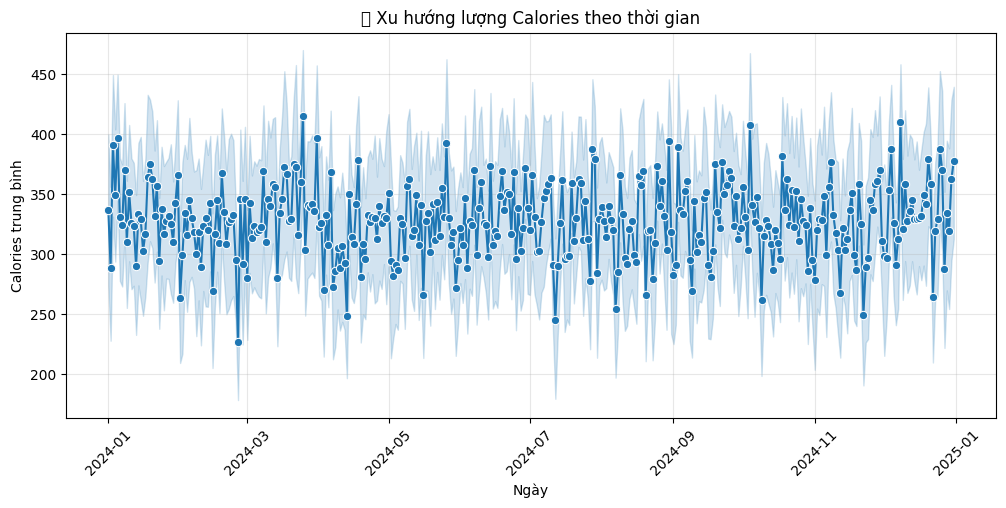

In [11]:
plt.figure(figsize=(12,5))
sns.lineplot(x='date', y='calories_(kcal)', data=Nutrition_data, marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.title("📈 Xu hướng lượng Calories theo thời gian")
plt.xlabel("Ngày")
plt.ylabel("Calories trung bình")
plt.grid(alpha=0.3)
plt.show()


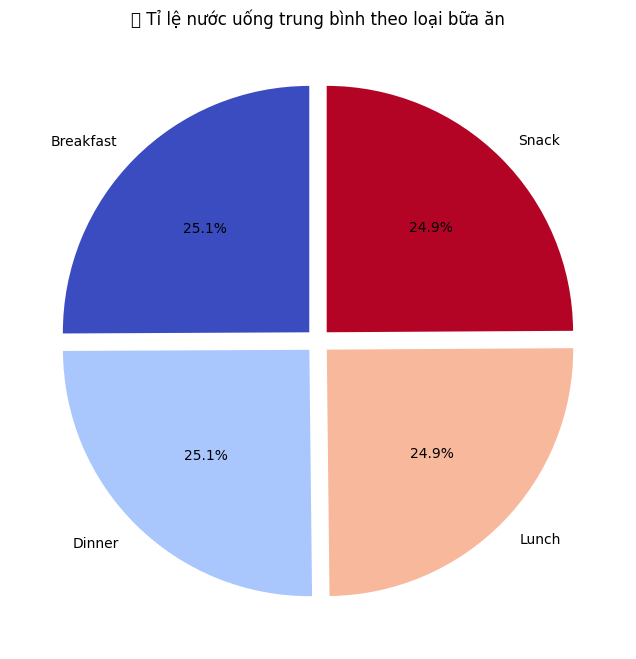

In [12]:
water_data = Nutrition_data.groupby('meal_type')['water_intake_(ml)'].mean()

plt.figure(figsize=(8,8))
water_data.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='coolwarm', explode=[0.05]*len(water_data))
plt.title("💧 Tỉ lệ nước uống trung bình theo loại bữa ăn")
plt.ylabel("")
plt.show()


# **IV.Hệ thống đề xuất món ăn**

**✅ Phân nhóm người dùng (Dựa trên giá trị dinh dưỡng)**


✅ Phân phối nhóm người dùng sau điều chỉnh:
user_group
Khác                       7522
Vận động viên               896
Người mắc bệnh tim mạch     646
Người ăn kiêng              521
Người cần tăng cân          415
Name: count, dtype: int64


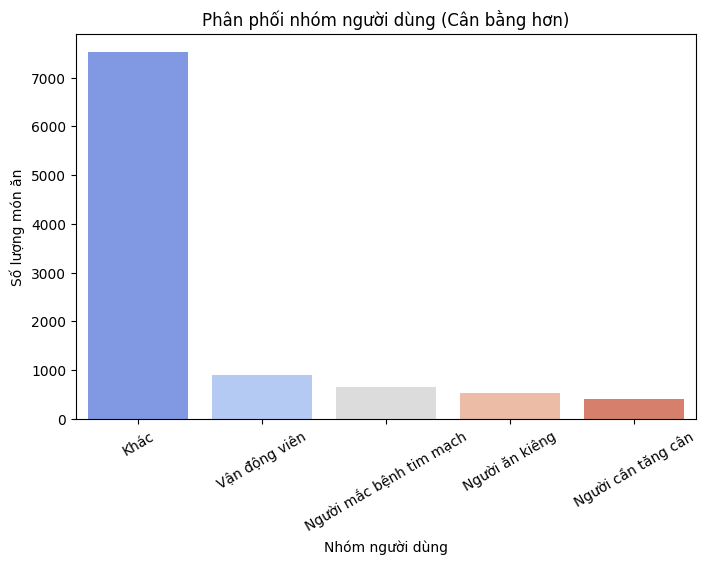

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# ✅ Hàm phân loại người dùng
def classify_user(row):
    if (
        row["protein_(g)"] >= 25  # Giảm ngưỡng để nhóm này có nhiều món hơn
        and row["carbohydrates_(g)"] >= 50  
        and row["fat_(g)"] <= 30  
        and row["calories_(kcal)"] >= 300  
    ):
        return "Vận động viên"
    
    elif (
        row["protein_(g)"] <= 18  
        and row["fat_(g)"] <= 18  
        and row["calories_(kcal)"] <= 280  
    ):
        return "Người ăn kiêng"
    
    elif (
        row["protein_(g)"] >= 20  
        and row["fat_(g)"] >= 25  
        and row["carbohydrates_(g)"] >= 60  
        and row["calories_(kcal)"] >= 400  
    ):
        return "Người cần tăng cân"
    
    elif (
        row["fat_(g)"] >= 20  
        and row["calories_(kcal)"] >= 300  
        and row["cholesterol_(mg)"] >= 50  
        and row["sodium_(mg)"] >= 700  
    ):
        return "Người mắc bệnh tim mạch"
    
    else:
        return "Khác"

# ✅ Áp dụng phân nhóm
Nutrition_data["user_group"] = Nutrition_data.apply(classify_user, axis=1)

# ✅ Kiểm tra lại phân phối nhóm
group_counts = Nutrition_data["user_group"].value_counts()
print("\n✅ Phân phối nhóm người dùng sau điều chỉnh:")
print(group_counts)

# ✅ Hiển thị biểu đồ phân phối
plt.figure(figsize=(8, 5))
sns.countplot(
    x="user_group", 
    data=Nutrition_data, 
    palette="coolwarm", 
    order=group_counts.index  # Sắp xếp theo số lượng giảm dần
)
plt.xticks(rotation=30)
plt.title("Phân phối nhóm người dùng (Cân bằng hơn)")
plt.xlabel("Nhóm người dùng")
plt.ylabel("Số lượng món ăn")
plt.show()


**✅ Chuẩn hóa dữ liệu dinh dưỡng**



📊 Phân phối các loại bữa ăn:
meal_type
Snack        5111
Lunch        1994
Breakfast    1668
Dinner       1227
Name: count, dtype: int64


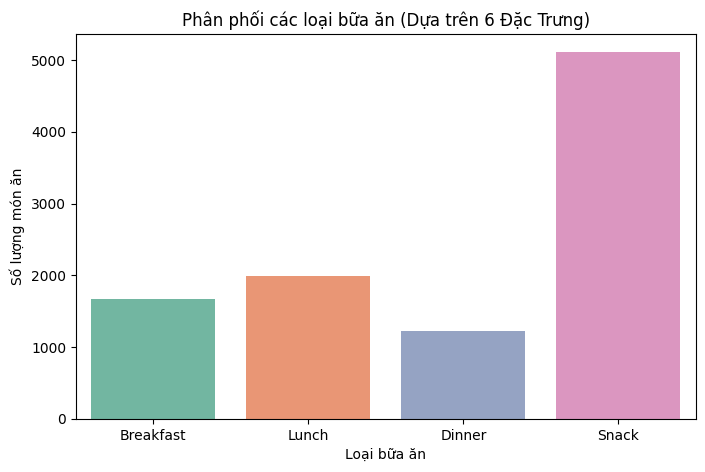


🔥 Bữa ăn: Breakfast
     food_item  calories_(kcal)  protein_(g)  carbohydrates_(g)  fat_(g)  \
13     Cookies              468         23.7               89.2      3.1   
18   Milkshake              353         24.0               96.2      6.8   
28      Butter              315         37.8               25.5     15.6   
36      Butter              437         41.2               71.7      6.0   
46      Cheese              359         31.6               30.8     13.3   
49      Yogurt              315          4.7               23.6      7.5   
51       Apple              485         49.2               81.2      5.8   
68  Strawberry              308         42.1               25.7      3.1   
72     Spinach              282         12.0               54.0      6.6   
83      Coffee              575         38.4               94.0      1.1   

    cholesterol_(mg)  sodium_(mg)  meal_type  
13               225          342  Breakfast  
18                17          305  Breakfast  
2

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Xử lý dữ liệu thiếu (NaN) trước khi phân loại
Nutrition_data = Nutrition_data.dropna(subset=["calories_(kcal)", "protein_(g)", "carbohydrates_(g)", "fat_(g)", "cholesterol_(mg)", "sodium_(mg)"])

# ✅ Hàm phân loại bữa ăn (cải tiến với 6 đặc trưng)

def classify_meal(row):
    if row["calories_(kcal)"] >= 420 and row["protein_(g)"] >= 15 and row["fat_(g)"] >= 10:
        return "Lunch"  # Giữ nguyên (đã đạt mục tiêu)
    elif row["calories_(kcal)"] >= 220 and row["carbohydrates_(g)"] >= 22 and row["fat_(g)"] <= 18:
        return "Breakfast"  # Giữ nguyên (đã hợp lý)
    elif row["calories_(kcal)"] >= 340 and row["fat_(g)"] >= 10 and row["carbohydrates_(g)"] >= 25:
        return "Dinner"  # Giảm nhẹ ngưỡng Calories để tăng Dinner
    else:
        return "Snack"  # Tăng ngưỡng Calories lên ≥ 250 và Carbs ≥ 15 để giảm Snack

# ✅ Áp dụng vào dữ liệu
Nutrition_data["meal_type"] = Nutrition_data.apply(classify_meal, axis=1)

# ✅ Kiểm tra phân phối bữa ăn
print("📊 Phân phối các loại bữa ăn:")
print(Nutrition_data["meal_type"].value_counts())

# ✅ Hiển thị biểu đồ phân phối bữa ăn
plt.figure(figsize=(8, 5))
sns.countplot(x=Nutrition_data["meal_type"], palette="Set2", order=["Breakfast", "Lunch", "Dinner", "Snack"])
plt.title("Phân phối các loại bữa ăn (Dựa trên 6 Đặc Trưng)")
plt.xlabel("Loại bữa ăn")
plt.ylabel("Số lượng món ăn")
plt.show()

# ✅ Hiển thị 10 món ăn đầu tiên của từng loại bữa ăn
for meal in ["Breakfast", "Lunch", "Dinner", "Snack"]:
    print(f"\n🔥 Bữa ăn: {meal}")
    print(
        Nutrition_data[Nutrition_data["meal_type"] == meal][
            ["food_item", "calories_(kcal)", "protein_(g)", "carbohydrates_(g)", "fat_(g)", "cholesterol_(mg)", "sodium_(mg)", "meal_type"]
        ].head(10)
    )


In [15]:
import pandas as pd
import joblib
import os
from sklearn.preprocessing import StandardScaler

# ✅ Chọn 6 đặc trưng quan trọng
nutrition_cols = [
    "calories_(kcal)", "protein_(g)", "carbohydrates_(g)", 
    "fat_(g)", "cholesterol_(mg)", "sodium_(mg)"
]

# ✅ Kiểm tra cột tồn tại trong dataset
nutrition_cols = [col for col in nutrition_cols if col in Nutrition_data.columns]

# ✅ Xử lý NaN (chỉ thay thế nếu có NaN)
if Nutrition_data[nutrition_cols].isnull().sum().sum() > 0:
    print("⚠️ Có dữ liệu NaN, đang thay thế bằng giá trị trung bình...")
    Nutrition_data[nutrition_cols] = Nutrition_data[nutrition_cols].fillna(
        Nutrition_data[nutrition_cols].mean()
    )

# ✅ Chuẩn hóa dữ liệu với StandardScaler
scaler = StandardScaler()
Nutrition_data_scaled = Nutrition_data.copy()  # Giữ nguyên bản gốc
Nutrition_data_scaled[nutrition_cols] = scaler.fit_transform(Nutrition_data[nutrition_cols])

# ✅ Tạo thư mục lưu model nếu chưa có
model_dir = "model"
os.makedirs(model_dir, exist_ok=True)

# ✅ Lưu scaler vào file
scaler_path = os.path.join(model_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler đã được lưu tại: {scaler_path}")

# ✅ Kiểm tra dữ liệu sau khi chuẩn hóa
print("✅ Dữ liệu sau khi chuẩn hóa (5 dòng đầu):")
print(Nutrition_data_scaled[nutrition_cols].head())


✅ Scaler đã được lưu tại: model\scaler.pkl
✅ Dữ liệu sau khi chuẩn hóa (5 dòng đầu):
   calories_(kcal)  protein_(g)  carbohydrates_(g)   fat_(g)  \
0        -0.977919     1.194297           1.136774 -1.692330   
1        -1.654335     0.967849          -1.415645 -1.572143   
2        -0.642872     0.111593           0.968804  0.025639   
3        -1.338253     1.265062          -0.199686 -0.660135   
4         1.089257     0.592795           0.848303  1.524443   

   cholesterol_(mg)  sodium_(mg)  
0         -0.307781     0.882133  
1         -0.628307     0.632110  
2          0.058535    -0.704818  
3         -1.589887    -0.663148  
4         -0.044491    -0.486048  


**✅ Tính toán ma trận tương đồng giữa các món ăn**


In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# ✅ Kiểm tra nếu cột "food_item" tồn tại
if "food_item" in Nutrition_data.columns:
    # ✅ Chọn 6 đặc trưng chính
    nutrition_cols = [
        "calories_(kcal)", "protein_(g)", "carbohydrates_(g)", 
        "fat_(g)", "cholesterol_(mg)", "sodium_(mg)"
    ]

    # ✅ Kiểm tra xem các cột này có tồn tại trong dữ liệu không
    nutrition_cols = [col for col in nutrition_cols if col in Nutrition_data.columns]

    # ✅ Tạo ma trận chỉ chứa thông tin dinh dưỡng
    food_features = Nutrition_data.set_index("food_item")[nutrition_cols]

    # ✅ Xử lý NaN (nếu có)
    food_features = food_features.fillna(0)

    # ✅ Tính toán độ tương đồng giữa các món ăn bằng Cosine Similarity
    food_similarity = cosine_similarity(food_features)

    # ✅ Chuyển ma trận tương đồng thành DataFrame
    food_sim_df = pd.DataFrame(food_similarity, index=food_features.index, columns=food_features.index)

    print("✅ Ma trận tương đồng giữa các món ăn đã tạo xong!\n")
    print(food_sim_df.head())  # Hiển thị 5 dòng đầu của ma trận tương đồng

else:
    print("❌ Lỗi: Cột 'food_item' không tồn tại trong dữ liệu.")


✅ Ma trận tương đồng giữa các món ăn đã tạo xong!

food_item           Eggs     Apple  Chicken Breast    Banana    Banana  \
food_item                                                                
Eggs            1.000000  0.987967        0.887280  0.979532  0.758648   
Apple           0.987967  1.000000        0.816410  0.950268  0.663317   
Chicken Breast  0.887280  0.816410        1.000000  0.897637  0.946666   
Banana          0.979532  0.950268        0.897637  1.000000  0.819552   
Banana          0.758648  0.663317        0.946666  0.819552  1.000000   

food_item           Oats    Carrot   Cookies     Apple    Quinoa  ...  \
food_item                                                         ...   
Eggs            0.751307  0.981719  0.761193  0.694553  0.998095  ...   
Apple           0.670439  0.990438  0.731988  0.599581  0.989609  ...   
Chicken Breast  0.955299  0.798200  0.864542  0.896687  0.879927  ...   
Banana          0.774019  0.963689  0.689964  0.761706  0.976756 

**✅ Xây dựng hệ thống**


In [17]:
# Huấn luyện mô hình KNN
knn_model = NearestNeighbors(metric="cosine", algorithm="brute")
knn_model.fit(Nutrition_data[nutrition_cols])


# Hàm gợi ý món ăn
def recommend_similar_foods(food_name, top_n=5):
    if food_name not in food_sim_df.index:
        return []
    return food_sim_df.loc[food_name].sort_values(ascending=False).index[1:top_n+1].tolist()


# Gợi ý món ăn dựa trên nội dung
def recommend_menu_for_user_group(user_group, meal_type='Bữa trưa', top_n=5):
    # Lọc các món ăn thuộc nhóm người dùng
    filtered_foods = Nutrition_data[Nutrition_data['user_group'] == user_group]
    # Chọn món ăn phù hợp cho bữa ăn
    recommended_meals = filtered_foods[filtered_foods['meal_type'] == meal_type]
    return recommended_meals.head(top_n)['food_item'].tolist()
    food_idx = Nutrition_data[Nutrition_data["food_item"] == food_name].index[0]
    distances, indices = knn_model.kneighbors([Nutrition_data_normalized.loc[food_idx, nutrient_features]], n_neighbors=top_n+1)
    return Nutrition_data.iloc[indices[0][1:]]["food_item"].tolist()


In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from imblearn.over_sampling import SMOTE
import numpy as np

# ✅ Mã hóa nhóm người dùng
label_encoder = LabelEncoder()
Nutrition_data["user_group_encoded"] = label_encoder.fit_transform(Nutrition_data["user_group"])

# ✅ Lựa chọn đặc trưng
feature_cols = ["calories_(kcal)", "protein_(g)", "carbohydrates_(g)",
                "fat_(g)", "cholesterol_(mg)", "sodium_(mg)"]

X = Nutrition_data[feature_cols]
y = Nutrition_data["user_group_encoded"]

# ✅ Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=42, stratify=y)

# ✅ Xử lý mất cân bằng (SMOTE)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ✅ Cải thiện mô hình với Hyperparameter Tuning
rf = RandomForestClassifier(n_estimators=100, max_depth=6, max_features="sqrt", class_weight="balanced", random_state=42)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.07, max_depth=5, reg_alpha=0.1, reg_lambda=0.3, 
                    subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric="mlogloss")
logreg = LogisticRegression(max_iter=500, C=1.0, penalty="l2")  # Tăng C để giảm bias

# ✅ Voting Classifier tối ưu
voting_clf = VotingClassifier(estimators=[
    ("Random Forest", rf),
    ("XGBoost", xgb),
    ("Logistic Regression", logreg)
], voting="soft")

# ✅ Huấn luyện với Cross-Validation
cv_scores = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring="accuracy")

# ✅ Huấn luyện mô hình chính thức
voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

# ✅ Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

# ✅ Xuất kết quả
print("\n🔥 Đánh giá mô hình sau tối ưu:")
print(f"   - Accuracy (test)  = {accuracy:.4f}")
print(f"   - F1-score (test)  = {f1:.4f}")
print(f"   - Mean CV Accuracy = {np.mean(cv_scores):.4f}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



🔥 Đánh giá mô hình sau tối ưu:
   - Accuracy (test)  = 0.9878
   - F1-score (test)  = 0.9879
   - Mean CV Accuracy = 0.9952
                         precision    recall  f1-score   support

                   Khác       1.00      0.99      0.99      3761
     Người cần tăng cân       0.91      0.97      0.94       208
Người mắc bệnh tim mạch       0.95      1.00      0.97       323
         Người ăn kiêng       0.99      0.98      0.99       260
          Vận động viên       0.99      0.97      0.98       448

               accuracy                           0.99      5000
              macro avg       0.97      0.98      0.98      5000
           weighted avg       0.99      0.99      0.99      5000




🔥 Đánh giá mô hình:
   - Accuracy  = 0.9878
   - F1-score  = 0.9879

📌 Classification Report:
                         precision    recall  f1-score   support

                   Khác       1.00      0.99      0.99      3761
     Người cần tăng cân       0.91      0.97      0.94       208
Người mắc bệnh tim mạch       0.95      1.00      0.97       323
         Người ăn kiêng       0.99      0.98      0.99       260
          Vận động viên       0.99      0.97      0.98       448

               accuracy                           0.99      5000
              macro avg       0.97      0.98      0.98      5000
           weighted avg       0.99      0.99      0.99      5000



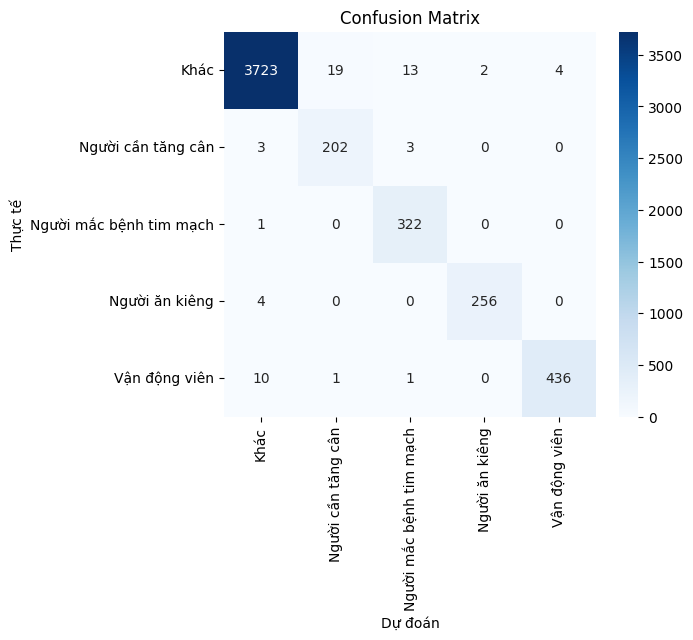

In [19]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, label_encoder):
    """
    Đánh giá mô hình với tập kiểm tra và hiển thị các chỉ số hiệu suất.
    """
    # ✅ Dự đoán
    y_pred = model.predict(X_test)

    # ✅ Tính toán độ chính xác và F1-score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ✅ Báo cáo phân loại
    print("\n🔥 Đánh giá mô hình:")
    print(f"   - Accuracy  = {accuracy:.4f}")
    print(f"   - F1-score  = {f1:.4f}")
    print("\n📌 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # ✅ Hiển thị Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(voting_clf, X_test, y_test, label_encoder)


**Tinh chỉnh mô hình tốt nhất (Random Forest)**

In [20]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Định nghĩa mô hình Random Forest ban đầu
rf_model = RandomForestClassifier(random_state=42)

# Định nghĩa bộ siêu tham số cần tối ưu
param_grid = {
    'n_estimators': [50, 100, 200, 300],       # Số lượng cây trong rừng
    'max_depth': [None, 10, 20, 30],           # Độ sâu tối đa của cây
    'min_samples_split': [2, 4, 6],            # Số mẫu tối thiểu để chia node
    'min_samples_leaf': [1, 2, 4],             # Số lá tối thiểu
    'bootstrap': [True, False]                 # Có bootstrap hay không
}

# Tìm kiếm siêu tham số bằng RandomizedSearchCV
rf_tuned = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_grid,
    n_iter=20,  # Số lần thử nghiệm
    cv=5,  # Cross-validation 5-Fold
    verbose=2,
    n_jobs=-1,  # Sử dụng tất cả CPU
    random_state=42
)

# ✅ Huấn luyện mô hình với tập huấn luyện
rf_tuned.fit(X_train, y_train)

# ✅ Hiển thị bộ siêu tham số tối ưu
print("🔎 Best Parameters:", rf_tuned.best_params_)

# ✅ Dự đoán trên tập kiểm tra
y_pred = rf_tuned.best_estimator_.predict(X_test)

# ✅ Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Độ chính xác Random Forest sau tinh chỉnh: {accuracy:.4f}")

# ✅ Lưu mô hình đã tối ưu
model_path = "model/random_forest_best.pkl"
joblib.dump(rf_tuned.best_estimator_, model_path)

print(f"✅ Mô hình đã được lưu tại: {model_path}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
🔎 Best Parameters: {'n_estimators': 200, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': False}
🎯 Độ chính xác Random Forest sau tinh chỉnh: 0.9932
✅ Mô hình đã được lưu tại: model/random_forest_best.pkl


In [21]:
import joblib

# Định nghĩa đường dẫn mô hình đã lưu
model_path = "model/random_forest_best.pkl"

# Tải lại mô hình
rf_loaded = joblib.load(model_path)

print("✅ Mô hình Random Forest đã được tải lại thành công!")


✅ Mô hình Random Forest đã được tải lại thành công!


**So sánh với các mô hình khác**

In [22]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import numpy as np
import joblib

# Định nghĩa đường dẫn thư mục trong project
model_dir = "model"
model_path = os.path.join(model_dir, "svm_best.pkl")

# Tạo thư mục nếu chưa tồn tại
os.makedirs(model_dir, exist_ok=True)

# 🔍 Chuyển `y_train` thành dạng numpy.array để tránh lỗi
y_train = np.array(y_train)
y_test = np.array(y_test)

# 🎯 Danh sách siêu tham số cần thử nghiệm cho SVM
param_grid_svm = {
    "C": [0.1, 1, 10, 100],  # Hệ số điều chỉnh độ phạt
    "gamma": ["scale", "auto", 0.01, 0.1, 1],  # Tham số kernel
    "kernel": ["rbf", "poly", "sigmoid"]  # Chọn kernel phù hợp
}

# ✅ Khởi tạo mô hình SVM
svm_model = SVC(probability=True, random_state=42)

# 🔍 Dùng RandomizedSearchCV để tối ưu siêu tham số
svm_tuned = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_grid_svm,
    n_iter=10,  # Chỉ thử 10 tổ hợp thay vì toàn bộ
    cv=3,  # Giảm từ 5-Fold xuống 3-Fold để tăng tốc độ
    verbose=2,
    n_jobs=-1
)

# 🚀 Huấn luyện SVM với tập train
svm_tuned.fit(X_train, y_train)

# 📌 Hiển thị bộ siêu tham số tối ưu
best_params_svm = svm_tuned.best_params_
print("📌 Best Parameters SVM:", best_params_svm)

# ✅ Khởi tạo lại mô hình với tham số tốt nhất
best_svm = SVC(
    **best_params_svm,
    probability=True,
    random_state=42
)

# 🚀 Huấn luyện lại mô hình
best_svm.fit(X_train, y_train)

# 🎯 Đánh giá mô hình trên tập kiểm tra
y_pred_svm = best_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"🎯 Độ chính xác SVM sau tinh chỉnh: {accuracy_svm:.4f}")
joblib.dump(best_svm, model_path)
print(f"✅ Mô hình SVM đã được lưu tại: {model_path}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits
📌 Best Parameters SVM: {'kernel': 'rbf', 'gamma': 1, 'C': 100}
🎯 Độ chính xác SVM sau tinh chỉnh: 0.9304
✅ Mô hình SVM đã được lưu tại: model\svm_best.pkl


In [23]:
import joblib

# Định nghĩa đường dẫn mô hình đã lưu
model_path = "model/svm_best.pkl"

# Tải lại mô hình
xgb_loaded = joblib.load(model_path)

print("✅ Mô hình SVM đã được tải lại thành công!")


✅ Mô hình SVM đã được tải lại thành công!


**3️⃣ Triển khai mô hình vào Web App Flask**
